<a href="https://colab.research.google.com/github/joyaldesai/ML-PROJECT/blob/main/Bike_Sharing_Demand_Prediction(Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <b><u> Project Title : Seoul Bike Sharing Demand Prediction </u></b>

## <b> Problem Description </b>

### Currently Rental bikes are introduced in many urban cities for the enhancement of mobility comfort. It is important to make the rental bike available and accessible to the public at the right time as it lessens the waiting time. Eventually, providing the city with a stable supply of rental bikes becomes a major concern. The crucial part is the prediction of bike count required at each hour for the stable supply of rental bikes.


## <b> Data Description </b>

### <b> The dataset contains weather information (Temperature, Humidity, Windspeed, Visibility, Dewpoint, Solar radiation, Snowfall, Rainfall), the number of bikes rented per hour and date information.</b>


### <b>Attribute Information: </b>

* ### Date : year-month-day
* ### Rented Bike count - Count of bikes rented at each hour
* ### Hour - Hour of he day
* ### Temperature-Temperature in Celsius
* ### Humidity - %
* ### Windspeed - m/s
* ### Visibility - 10m
* ### Dew point temperature - Celsius
* ### Solar radiation - MJ/m2
* ### Rainfall - mm
* ### Snowfall - cm
* ### Seasons - Winter, Spring, Summer, Autumn
* ### Holiday - Holiday/No holiday
* ### Functional Day - NoFunc(Non Functional Hours), Fun(Functional hours)

**Import Dependancy**

In [315]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
import math
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures

In [316]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [317]:
# Import csv file and put the data in data variable name
df = pd.read_csv('/content/drive/MyDrive/ML project /ML PROJECT (REGRESSION)/Copy of SeoulBikeData.csv', encoding = 'unicode_escape')

In [318]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [319]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')

In [320]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [321]:
df.isnull().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


## **Exploratory Data Analysis (EDA)**

In [322]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')

#### **Relationship b/w Seasons and Rented Bike Count**

In [323]:
a = df['Seasons'].value_counts()
a

,count
Seasons,
Spring,2208
Summer,2208
Autumn,2184
Winter,2160


In [324]:
a = df.groupby('Seasons')['Rented Bike Count'].sum()
a

,Rented Bike Count
Seasons,
Autumn,1790002
Spring,1611909
Summer,2283234
Winter,487169


Text(0.5, 0, 'Seasons name')

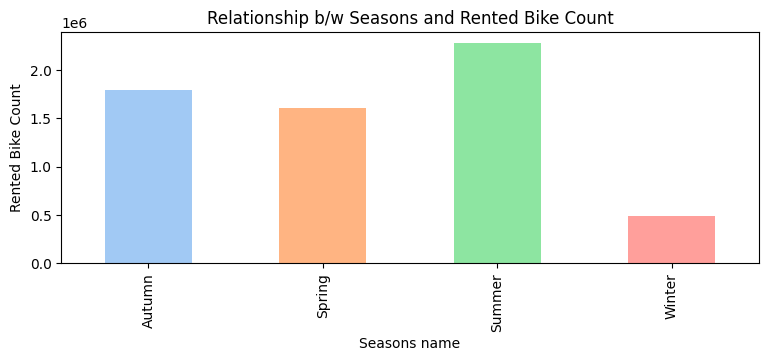

In [325]:
plt.figure(figsize = (9,3))
a.plot(kind = 'bar',color = sns.color_palette('pastel'))
plt.title('Relationship b/w Seasons and Rented Bike Count')
plt.ylabel('Rented Bike Count')
plt.xlabel('Seasons name')

#### **Relationship b/w Holiday Seasons and Rented Bike Count**

In [326]:
a = df.groupby('Holiday')['Rented Bike Count'].sum()
a

,Rented Bike Count
Holiday,
Holiday,215895
No Holiday,5956419


Text(0.5, 0, 'Holiday')

/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


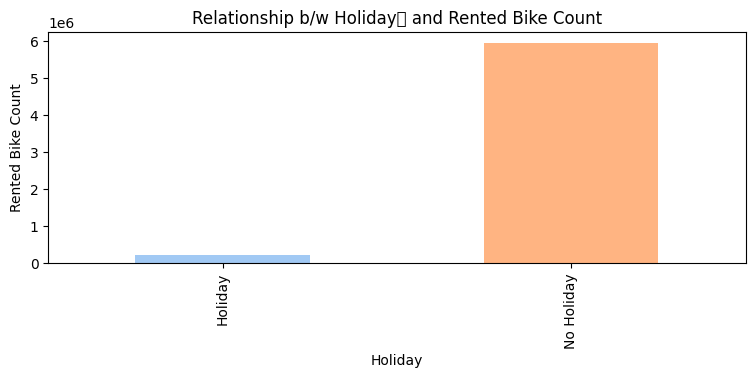

In [327]:
plt.figure(figsize = (9,3))
a.plot(kind = 'bar',color = sns.color_palette('pastel'))
plt.title('Relationship b/w Holiday	 and Rented Bike Count')
plt.ylabel('Rented Bike Count')
plt.xlabel('Holiday')

In [328]:
a = df.groupby(['Holiday','Seasons'])['Rented Bike Count'].sum().unstack()
a

Seasons,Autumn,Spring,Summer,Winter
Holiday,,,,
Holiday,91018,45742,49063,30072
No Holiday,1698984,1566167,2234171,457097


Text(0.5, 0, 'Holiday')

/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


<Figure size 900x300 with 0 Axes>

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


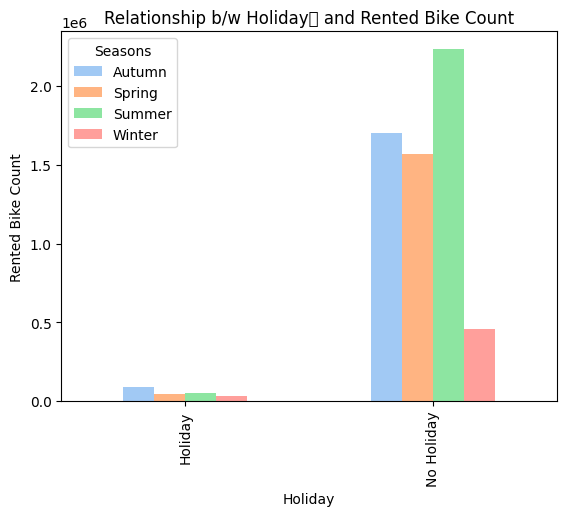

In [329]:
plt.figure(figsize = (9,3))
a.plot(kind = 'bar',color = sns.color_palette('pastel'))
plt.title('Relationship b/w Holiday	 and Rented Bike Count')
plt.ylabel('Rented Bike Count')
plt.xlabel('Holiday')

#### **Relationship b/w seasons humidity and bike count**

In [330]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')

Text(0.5, 0, 'Humidity')

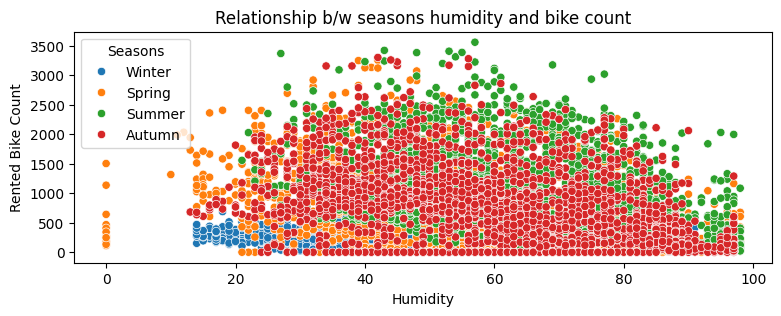

In [331]:
plt.figure(figsize = (9,3))
sns.scatterplot(x = 'Humidity(%)',y = 'Rented Bike Count',hue = 'Seasons',data = df)
plt.title('Relationship b/w seasons humidity and bike count')
plt.ylabel('Rented Bike Count')
plt.xlabel('Humidity')

#### **Temperature, Rented Bike Count for diffrent Seasons**

Text(0.5, 0, 'Temperature')

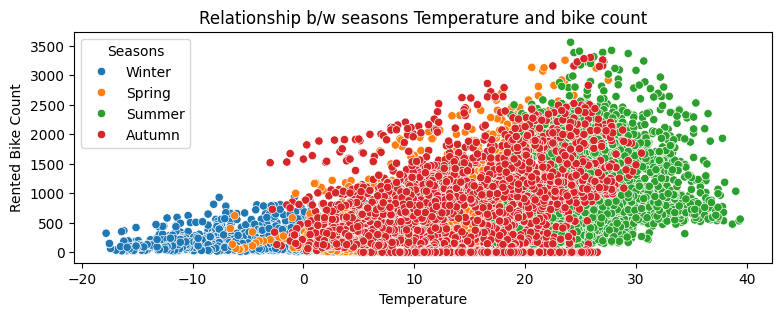

In [332]:
plt.figure(figsize = (9,3))
sns.scatterplot(x = 'Temperature(°C)',y = 'Rented Bike Count',hue = 'Seasons',data = df)
plt.title('Relationship b/w seasons Temperature and bike count')
plt.ylabel('Rented Bike Count')
plt.xlabel('Temperature')

#### **Wind speed , Rented Bike Count for diffrent Seasons**

Text(0.5, 0, 'Wind speed')

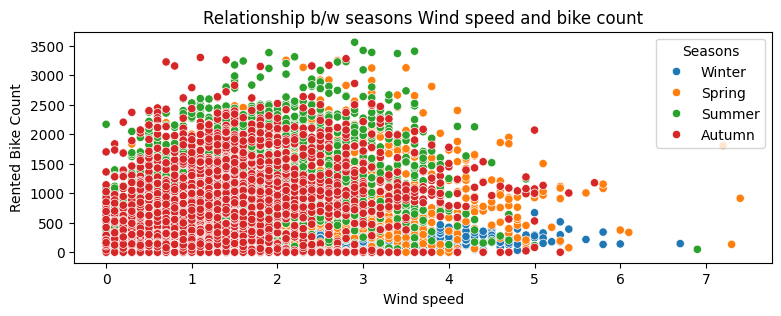

In [333]:
plt.figure(figsize = (9,3))
sns.scatterplot(x = 'Wind speed (m/s)',y = 'Rented Bike Count',hue = 'Seasons',data = df)
plt.title('Relationship b/w seasons Wind speed and bike count')
plt.ylabel('Rented Bike Count')
plt.xlabel('Wind speed')

#### **Visibility (10m), Rented Bike Count for diffrent Seasons**

Text(0.5, 0, 'Visibility')

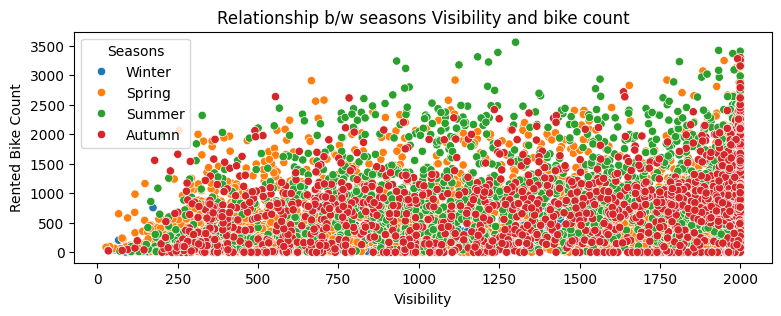

In [334]:
plt.figure(figsize = (9,3))
sns.scatterplot(x = 'Visibility (10m)',y = 'Rented Bike Count',hue = 'Seasons',data = df)
plt.title('Relationship b/w seasons Visibility and bike count')
plt.ylabel('Rented Bike Count')
plt.xlabel('Visibility')

#### **Solar Radiation (MJ/m2), Rented Bike Count for diffrent Seasons**

Text(0.5, 0, 'Visibility')

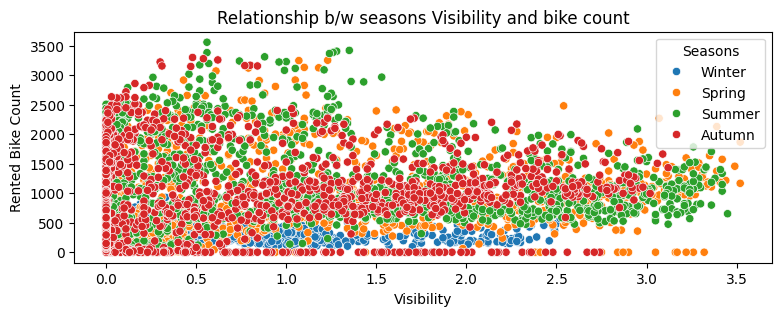

In [335]:
plt.figure(figsize = (9,3))
sns.scatterplot(x = 'Solar Radiation (MJ/m2)',y = 'Rented Bike Count',hue = 'Seasons',data = df)
plt.title('Relationship b/w seasons Visibility and bike count')
plt.ylabel('Rented Bike Count')
plt.xlabel('Visibility')

#### **Rainfall(mm), Rented Bike Count for diffrent Seasons**

Text(0.5, 0, 'Rainfall(mm)')

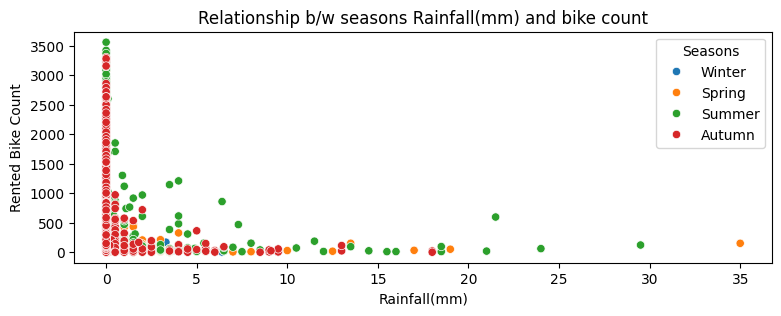

In [336]:
plt.figure(figsize = (9,3))
sns.scatterplot(x = 'Rainfall(mm)',y = 'Rented Bike Count',hue = 'Seasons',data = df)
plt.title('Relationship b/w seasons Rainfall(mm) and bike count')
plt.ylabel('Rented Bike Count')
plt.xlabel('Rainfall(mm)')

#### **Snowfall (cm), Rented Bike Count for diffrent Seasons**

Text(0.5, 0, 'Snowfall (cm)')

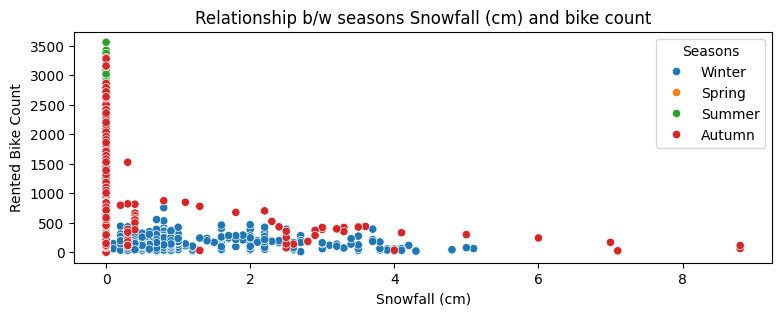

In [337]:
plt.figure(figsize = (9,3))
sns.scatterplot(x = 'Snowfall (cm)',y = 'Rented Bike Count',hue = 'Seasons',data = df)
plt.title('Relationship b/w seasons Snowfall (cm) and bike count')
plt.ylabel('Rented Bike Count')
plt.xlabel('Snowfall (cm)')

#### **Hour, Rented Bike Count for diffrent Seasons**

In [338]:
a = df.groupby(['Hour'])['Rented Bike Count'].sum()
a

,Rented Bike Count
Hour,
0,197633
1,155557
2,110095
3,74216
4,48396
5,50765
6,104961
7,221192
8,370731


Text(0.5, 0, 'Hour')

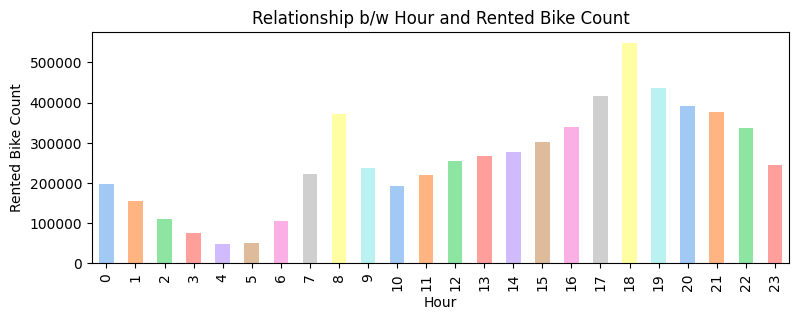

In [339]:
plt.figure(figsize = (9,3))
a.plot(kind = 'bar',color = sns.color_palette('pastel'))
plt.title('Relationship b/w Hour and Rented Bike Count')
plt.ylabel('Rented Bike Count')
plt.xlabel('Hour')

#### **Hour, Rented Bike Count for diffrent Seasons**

In [340]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')

In [341]:
a = df.groupby(['Functioning Day'])['Rented Bike Count'].sum()
a

,Rented Bike Count
Functioning Day,
No,0
Yes,6172314


Text(0.5, 0, 'Functioning Day\t')

/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


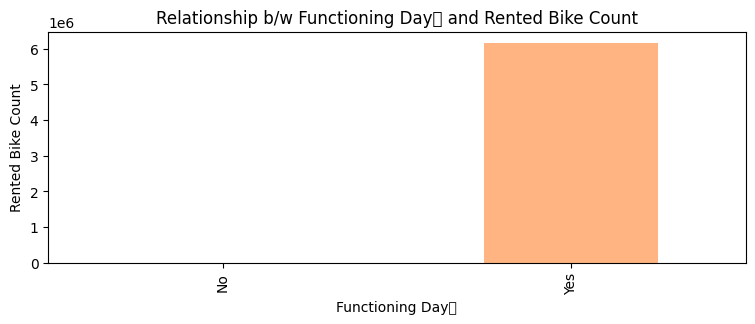

In [342]:
plt.figure(figsize = (9,3))
a.plot(kind = 'bar',color = sns.color_palette('pastel'))
plt.title('Relationship b/w Functioning Day	 and Rented Bike Count')
plt.ylabel('Rented Bike Count')
plt.xlabel('Functioning Day	')

## **Feature Engineering**

In [343]:
num_features = df.describe().columns
num_features

Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)'],
      dtype='object')

### **Correlation & scatter  plot 'Rented Bike Count'**

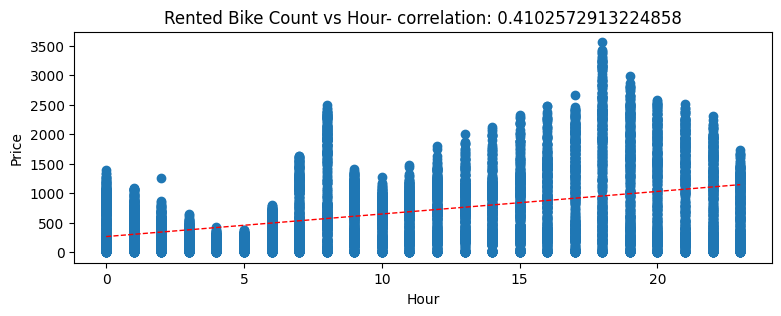

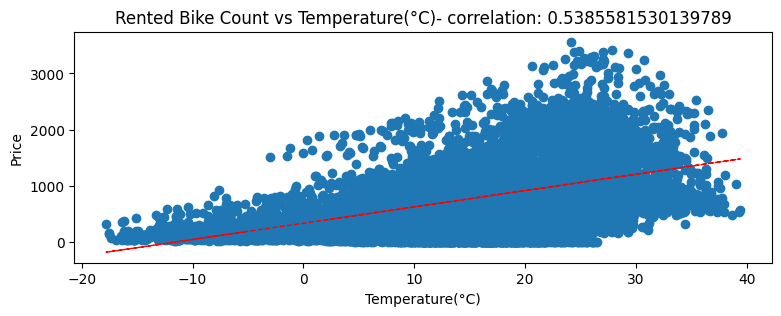

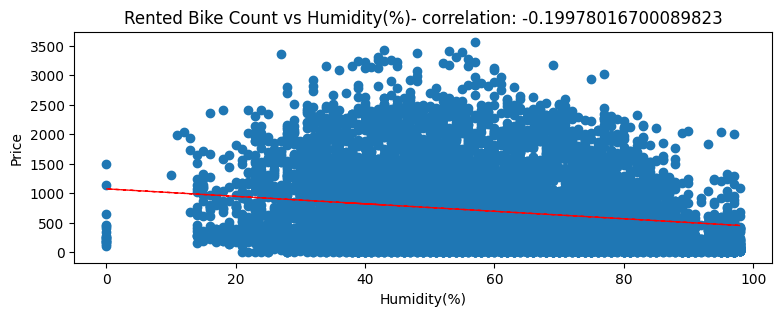

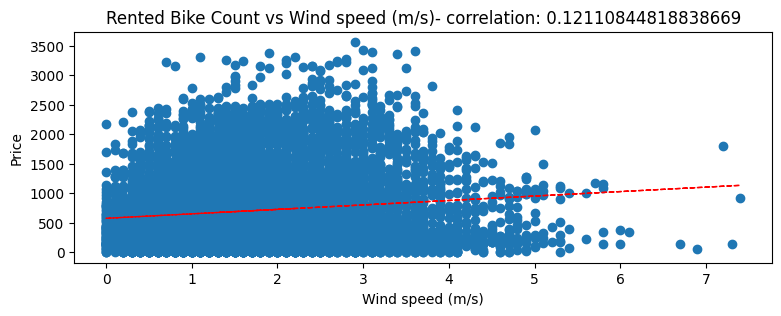

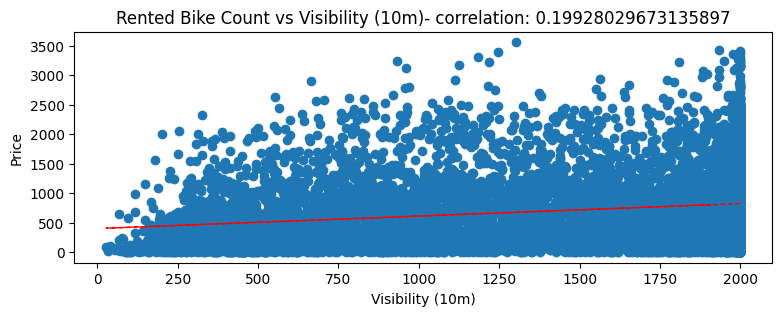

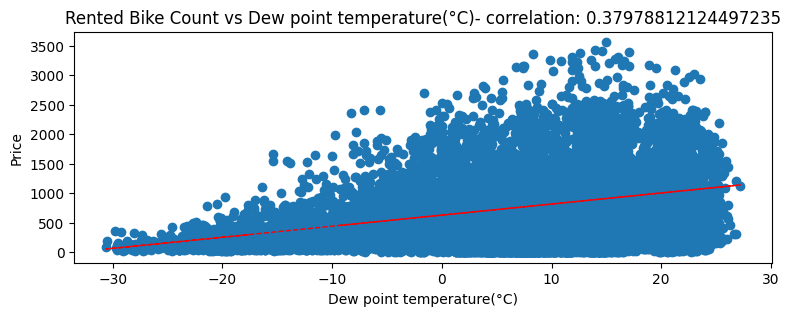

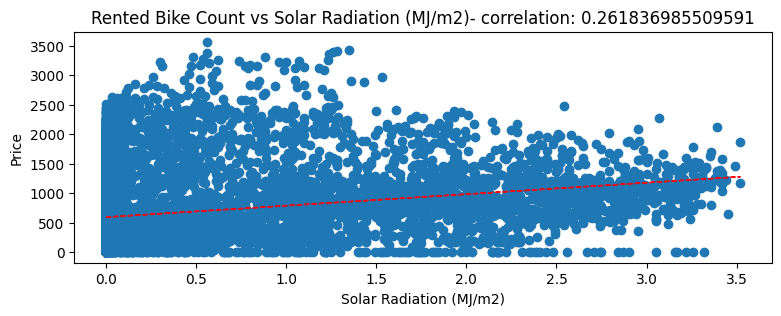

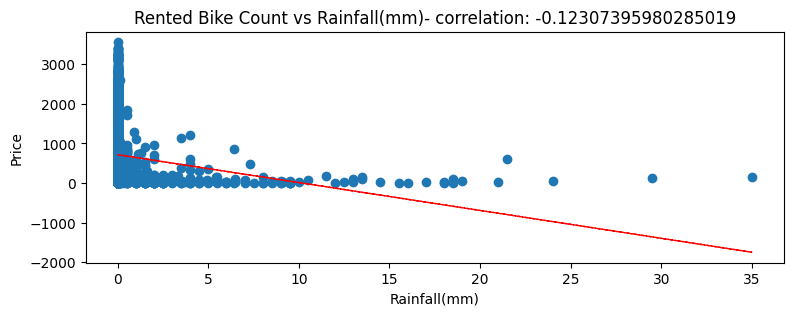

In [344]:
# Correlation & scatter plot 'Rented Bike Count'
for col in num_features[1:-1]:
  fig = plt.figure(figsize=(9,3))
  ax = fig.gca()
  feature =(df[col])
  label = df['Rented Bike Count']
  correlation = feature.corr(label)
  plt.scatter(x=feature, y=label)
  plt.xlabel(col)
  plt.ylabel('Price')
  ax.set_title('Rented Bike Count vs ' + col + '- correlation: ' + str(correlation))
  z = np.polyfit(df[col], df['Rented Bike Count'], 1)
  y_hat = np.poly1d(z)(df[col])

  plt.plot(df[col], y_hat, "r--", lw=1)

plt.show()

### **Feature incoding And creation**

In [345]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [346]:
df['Date'] =pd.to_datetime(df['Date'],format= '%d/%m/%Y')
df['day_of_week'] = df['Date'].dt.day_name()
df['month_name'] = df['Date'].dt.month_name()
df['year_name'] = df['Date'].map(lambda x: x.year).astype("object")

df.drop(['Date'],axis = 1,inplace = True)

In [347]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,day_of_week,month_name,year_name
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,December,2017
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,December,2017
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,December,2017
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,December,2017
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,December,2017


In [348]:
df['week'] = df['day_of_week'].apply(lambda x:'Weekend'  if x=='Saturday' or  x== 'Sunday' else 'Weekdays')

In [349]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,day_of_week,month_name,year_name,week
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,December,2017,Weekdays
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,December,2017,Weekdays
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,December,2017,Weekdays
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,December,2017,Weekdays
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,December,2017,Weekdays


<function matplotlib.pyplot.xlabel(xlabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['left', 'center', 'right'] | None" = None, **kwargs) -> 'Text'>

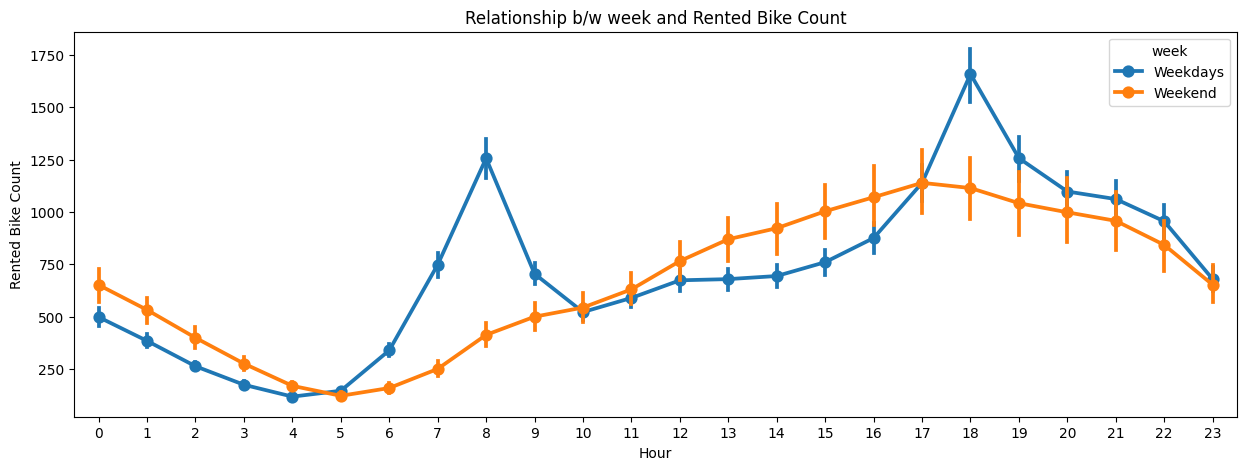

In [350]:
plt.figure(figsize=(15,5))
sns.pointplot(x=df["Hour"],y=df['Rented Bike Count'],hue=df['week'])
plt.title('Relationship b/w week and Rented Bike Count')
plt.ylabel('Rented Bike Count')
plt.xlabel

**Lets do some feature engineering on Hour column**

In [351]:
df['Hour'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [352]:
def hour(h):
  if h >= 17 and h <= 22:
    return 'Evening'
  elif h >= 7 and h <= 10:
    return 'Morning'
  elif h >= 11 and h <= 16:
    return 'Noon'
  else :
    return 'Night'

In [353]:
df['Hour'] = df['Hour'].apply(hour)

In [354]:
df['Hour']

,Hour
0,Night
1,Night
2,Night
3,Night
4,Night
...,...
8755,Evening
8756,Evening
8757,Evening
8758,Evening


#### **Correlation**

In [355]:
int_columns_df = df.select_dtypes(include=['int', 'float'])
int_columns_df

,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
0,254,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0
1,204,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0
2,173,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0
3,107,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0
4,78,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
8755,1003,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0
8756,764,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0
8757,694,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0
8758,712,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0


In [356]:
int_columns_df.corr()

,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
Rented Bike Count,1.000000,0.538558,-0.199780,0.121108,0.199280,0.379788,0.261837,-0.123074,-0.141804
Temperature(°C),0.538558,1.000000,0.159371,-0.036252,0.034794,0.912798,0.353505,0.050282,-0.218405
Humidity(%),-0.199780,0.159371,1.000000,-0.336683,-0.543090,0.536894,-0.461919,0.236397,0.108183
Wind speed (m/s),0.121108,-0.036252,-0.336683,1.000000,0.171507,-0.176486,0.332274,-0.019674,-0.003554
Visibility (10m),0.199280,0.034794,-0.543090,0.171507,1.000000,-0.176630,0.149738,-0.167629,-0.121695
Dew point temperature(°C),0.379788,0.912798,0.536894,-0.176486,-0.176630,1.000000,0.094381,0.125597,-0.150887
Solar Radiation (MJ/m2),0.261837,0.353505,-0.461919,0.332274,0.149738,0.094381,1.000000,-0.074290,-0.072301
Rainfall(mm),-0.123074,0.050282,0.236397,-0.019674,-0.167629,0.125597,-0.074290,1.000000,0.008500
Snowfall (cm),-0.141804,-0.218405,0.108183,-0.003554,-0.121695,-0.150887,-0.072301,0.008500,1.000000


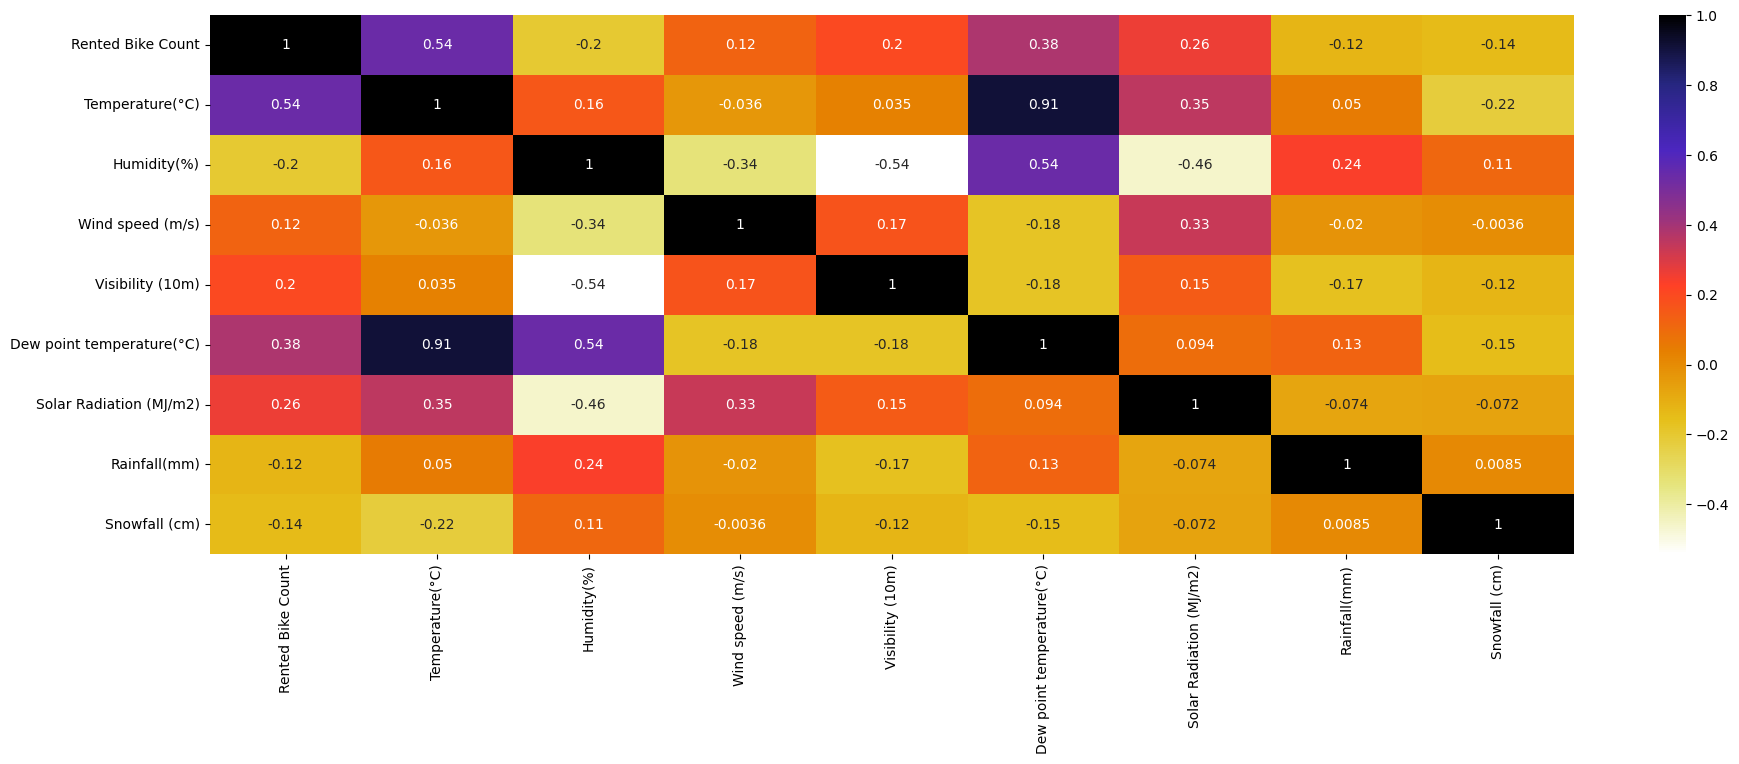

In [357]:
import seaborn as sns

#Using Pearson Correlation
plt.figure(figsize=(22,7))
cor = int_columns_df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.show()

In [358]:
df.columns

Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day', 'day_of_week', 'month_name', 'year_name',
       'week'],
      dtype='object')

In [359]:
df.drop('Dew point temperature(°C)',axis = 1, inplace = True)

In [360]:
df.columns

Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)',
       'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday',
       'Functioning Day', 'day_of_week', 'month_name', 'year_name', 'week'],
      dtype='object')

## **Data Pre-processing**

### **Feature Scaling**

In [361]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   object 
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   object 
 10  Holiday                  8760 non-null   object 
 11  Functioning Day          8760 non-null   object 
 12  day_of_week              8760 non-null   object 
 13  month_name               8760 non-null   object 
 14  year_name               

In [362]:
# Label Encoding
df = pd.get_dummies(df,drop_first=True,sparse=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   Rented Bike Count        8760 non-null   int64              
 1   Temperature(°C)          8760 non-null   float64            
 2   Humidity(%)              8760 non-null   int64              
 3   Wind speed (m/s)         8760 non-null   float64            
 4   Visibility (10m)         8760 non-null   int64              
 5   Solar Radiation (MJ/m2)  8760 non-null   float64            
 6   Rainfall(mm)             8760 non-null   float64            
 7   Snowfall (cm)            8760 non-null   float64            
 8   Hour_Morning             1 non-null      Sparse[bool, False]
 9   Hour_Night               1 non-null      Sparse[bool, False]
 10  Hour_Noon                1 non-null      Sparse[bool, False]
 11  Seasons_Spring           1 non

/tmp/ipython-input-2570675920.py:3: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  df.info()


In [363]:
df.head()

,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Hour_Morning,Hour_Night,...,month_name_January,month_name_July,month_name_June,month_name_March,month_name_May,month_name_November,month_name_October,month_name_September,year_name_2018,week_Weekend
0,254,-5.2,37,2.2,2000,0.0,0.0,0.0,False,True,...,False,False,False,False,False,False,False,False,False,False
1,204,-5.5,38,0.8,2000,0.0,0.0,0.0,False,True,...,False,False,False,False,False,False,False,False,False,False
2,173,-6.0,39,1.0,2000,0.0,0.0,0.0,False,True,...,False,False,False,False,False,False,False,False,False,False
3,107,-6.2,40,0.9,2000,0.0,0.0,0.0,False,True,...,False,False,False,False,False,False,False,False,False,False
4,78,-6.0,36,2.3,2000,0.0,0.0,0.0,False,True,...,False,False,False,False,False,False,False,False,False,False


In [364]:
x = df.drop('Rented Bike Count',axis = 1)
y = df['Rented Bike Count']

In [365]:
from sklearn.model_selection import train_test_split

In [366]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

**transforming X_train and X_test with yeo-johnson transformation**

In [367]:
from sklearn.preprocessing import PowerTransformer,StandardScaler,MinMaxScaler

In [368]:
scal = StandardScaler()
x_train = scal.fit_transform(x_train)
x_test = scal.transform(x_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1117: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  if np.may_share_memory(array, array_orig):
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1117: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtyp

## **Model Implementation**

### **Import Dependancy**

In [369]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
import math
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures

**Create a function for scores**

In [370]:
# Appending all models parameters to the corrosponding list
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


def score_metrix (model,X_train,X_test,Y_train,Y_test):

  '''
    train the model and gives mae, mse,rmse,r2,adj r2 score of the model

  '''
  #training the model
  model.fit(X_train,Y_train)

  # Training Score
  training  = model.score(X_train,Y_train)
  print("Training score  =", training)

  # Testing Score
  testing = model.score(X_test, Y_test)
  print("Testing score = ", testing)


  #predicting the Test set and evaluting the models

  if model == LinearRegression() or model == Lasso() or model == Ridge():
    Y_pred = model.predict(X_test)

    #finding mean_absolute_error
    MAE  = mean_absolute_error(Y_test**2,Y_pred**2)
    print("MAE :" , MAE)

    #finding mean_squared_error
    MSE  = mean_squared_error(Y_test**2,Y_pred**2)
    print("MSE :" , MSE)

    #finding root mean squared error
    RMSE = np.sqrt(MSE)
    print("RMSE :" ,RMSE)

    #finding the r2 score

    r2 = r2_score(Y_test**2,Y_pred**2)
    print("R2 :" ,r2)
    #finding the adjusted r2 score
    adj_r2=1-(1-r2_score(Y_test**2,Y_pred**2))*((X_test.shape[0]-1)/(X_test.shape[0]-X_test.shape[1]-1))
    print("Adjusted R2 : ",adj_r2,'\n')

  else:
    # for tree base models
    Y_pred = model.predict(X_test)

    #finding mean_absolute_error
    MAE  = mean_absolute_error(Y_test,Y_pred)
    print("MAE :" , MAE)

    #finding mean_squared_error
    MSE  = mean_squared_error(Y_test,Y_pred)
    print("MSE :" , MSE)

    #finding root mean squared error
    RMSE = np.sqrt(MSE)
    print("RMSE :" ,RMSE)

    #finding the r2 score

    r2 = r2_score(Y_test,Y_pred)
    print("R2 :" ,r2)
    #finding the adjusted r2 score
    adj_r2=1-(1-r2_score(Y_test,Y_pred))*((X_test.shape[0]-1)/(X_test.shape[0]-X_test.shape[1]-1))
    print("Adjusted R2 : ",adj_r2,'\n')



  print('*'*80)
  # print the cofficient and intercept of which model have these parameters and else we just pass them
  try :
    print("coefficient \n",model.coef_)
    print('\n')
    print("Intercept  = " ,model.intercept_)
  except:
    pass
  print('\n')
  print('*'*20, 'ploting the graph of Actual and predicted only with 80 observation', '*'*20)

  # ploting the graph of Actual and predicted only with 80 observation for better visualisation which model have these parameters and else we just pass them
  try:
    # ploting the line graph of actual and predicted values
    plt.figure(figsize=(15,7))
    plt.plot((Y_pred)[:80])
    plt.plot((np.array(Y_test)[:80]))
    plt.legend(["Predicted","Actual"])
    plt.show()
  except:
    pass

### **Linear Regression**

Training score  = 0.6495141881141844
Testing score =  0.6337855901336709
MAE : 298.1806224055435
MSE : 152581.85606542177
RMSE : 390.61727568736865
R2 : 0.6337855901336709
Adjusted R2 :  0.6265338196412683 

********************************************************************************
coefficient 
 [ 363.85365097 -135.46999025   16.75676451   36.38301676  -31.50673313
  -68.83617441   10.21629236 -109.68108134 -291.39195361 -206.55138109
  -10.9212955   -23.60554183  -33.90530715   31.08424075  175.12327045
  -17.99940183   -3.99819551  -26.32381684   -4.86886391   -8.66316098
    0.45542061  -82.82025229   -0.93358307  -32.89838125  -20.0360258
  -27.55882115   74.55959542  -17.89461231   34.29671952   34.27479196
   56.61335176   15.17241768    0.93358307  -23.42362894]


Intercept  =  704.7678367579907


******************** ploting the graph of Actual and predicted only with 80 observation ********************


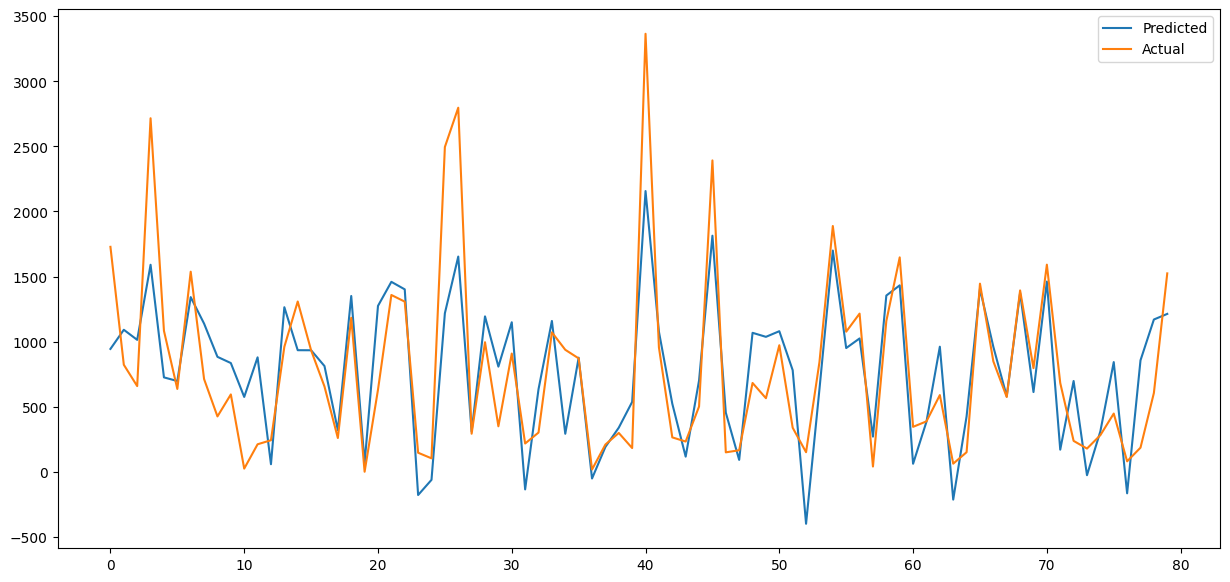

In [371]:
score_metrix(LinearRegression(),x_train,x_test,y_train,y_test)

### **Lasso with hyperparameter tuning**

In [372]:
L1 = Lasso() #creating variable
parameters = {'alpha': [1e-15,1e-13,1e-10,1e-8,1e-5,1e-4,1e-3,1e-2,1e-1,1,5,10,20,30,40,45,50,55,60,100,0.0014]} #lasso parameters
lasso_cv = GridSearchCV(L1, parameters, cv=5) #using gridsearchcv and cross validate the model

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.917e+08, tolerance: 2.348e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.010e+08, tolerance: 2.339e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.006e+08, tolerance: 2.304e

Training score  = 0.6494014595137529
Testing score =  0.6337619731772526
MAE : 297.90460515080264
MSE : 152591.6959814596
RMSE : 390.62987082590035
R2 : 0.6337619731772526
Adjusted R2 :  0.6265097350223467 

********************************************************************************


******************** ploting the graph of Actual and predicted only with 80 observation ********************


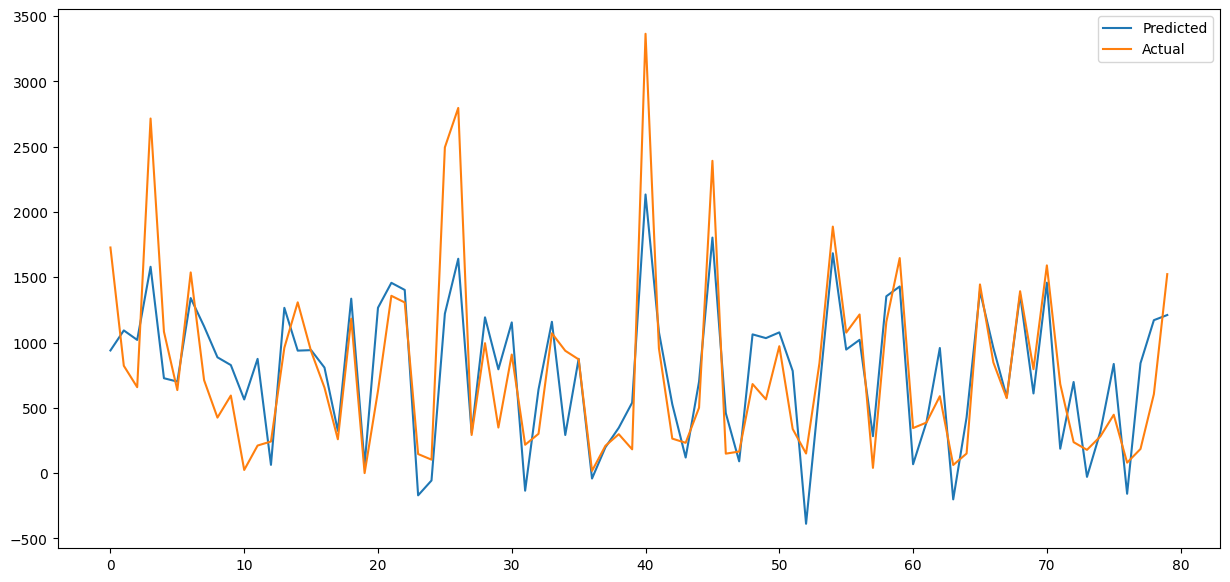

In [373]:
score_metrix(lasso_cv,x_train,x_test,y_train,y_test)

### **Ridge with hyperparameter tuning**

Training score  = 0.6495123535549361
Testing score =  0.6338186656036794
MAE : 298.1269175860638
MSE : 152568.0752952823
RMSE : 390.59963555446683
R2 : 0.6338186656036794
Adjusted R2 :  0.626567550071079 

********************************************************************************


******************** ploting the graph of Actual and predicted only with 80 observation ********************


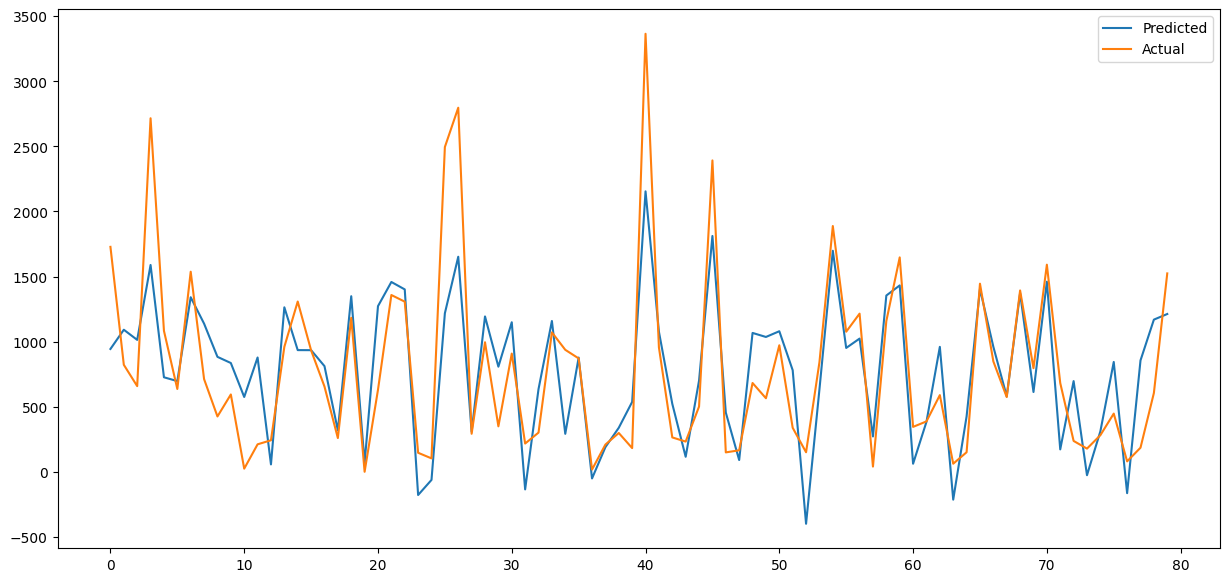

In [374]:
L2 = Ridge() #creating variable
parameters = {'alpha': [1e-15,1e-10,1e-8,1e-5,1e-4,1e-3,1e-2,1,5,10,20,30,40,45,50,55,60,100,0.5,1.5,1.6,1.7,1.8,1.9]} # giving parameters
L2_cv = GridSearchCV(L2, parameters, scoring='r2', cv=5) #using gridsearchcv and cross validate the model
score_metrix(L2_cv,x_train,x_test,y_train,y_test) # fit and evaluate model with score_matrix function

### **Polynomial**

In [375]:
poly = PolynomialFeatures(2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

#### **LinearRegression**

Training score  = 0.8363590591573928
Testing score =  0.7888314171938124
MAE : 202.7057625379923
MSE : 87982.59554842074
RMSE : 296.61860283606745
R2 : 0.7888314171938124
Adjusted R2 :  0.6701550504071058 

********************************************************************************
coefficient 
 [ 4.04111884e-13  2.29989721e+02 -1.07381504e+02  2.13304740e+01
  2.67456079e+01 -1.18458901e+02 -4.18434788e+02 -1.28370567e+01
 -9.76791179e+00 -1.93767335e+02 -3.83701917e+01  6.60313127e+00
  7.67582267e+00 -1.69903287e+01  8.26580404e-01  5.40067447e+00
 -2.44416731e+00 -2.04424414e+00 -4.17516191e+00 -1.89634991e-01
 -1.23996232e+00  9.40994822e-01  6.00489736e+00 -3.85955573e+00
 -8.65779118e+00 -1.41540919e+01  2.76460046e+00  3.24578710e+00
 -2.18142282e+00  2.95672344e+00  2.82001882e+00  5.49813369e+00
 -4.53912030e+00  3.85955573e+00 -4.81271304e+00 -1.38330515e+02
 -8.17238371e+01  9.07815395e+00 -3.54104939e+01 -5.92163519e+01
 -7.24891196e+01 -4.67158974e+01 -1.52028832e+02

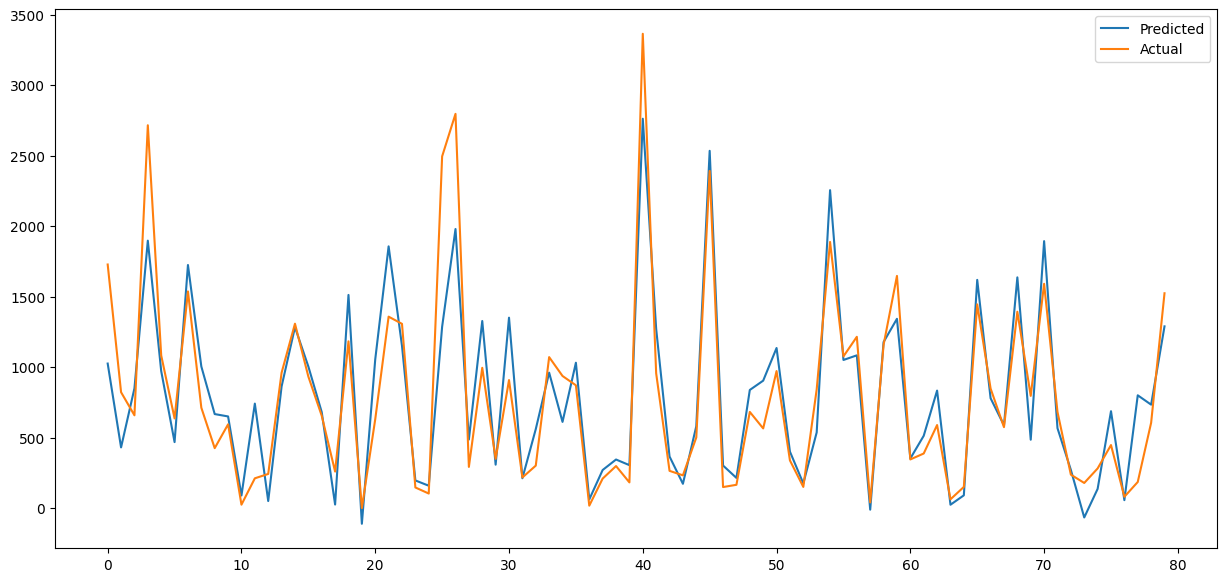

In [376]:
score_metrix(LinearRegression(), x_train_poly,x_test_poly,y_train,y_test)

### **Train Test split for Tree Base Models**
**because multicollinearty not effect tree base models**


Training score  = 1.0
Testing score =  0.770717437842731
MAE : 191.5
MSE : 95529.71689497717
RMSE : 309.078819874441
R2 : 0.770717437842731
Adjusted R2 :  0.7661771890871415 

********************************************************************************


******************** ploting the graph of Actual and predicted only with 80 observation ********************


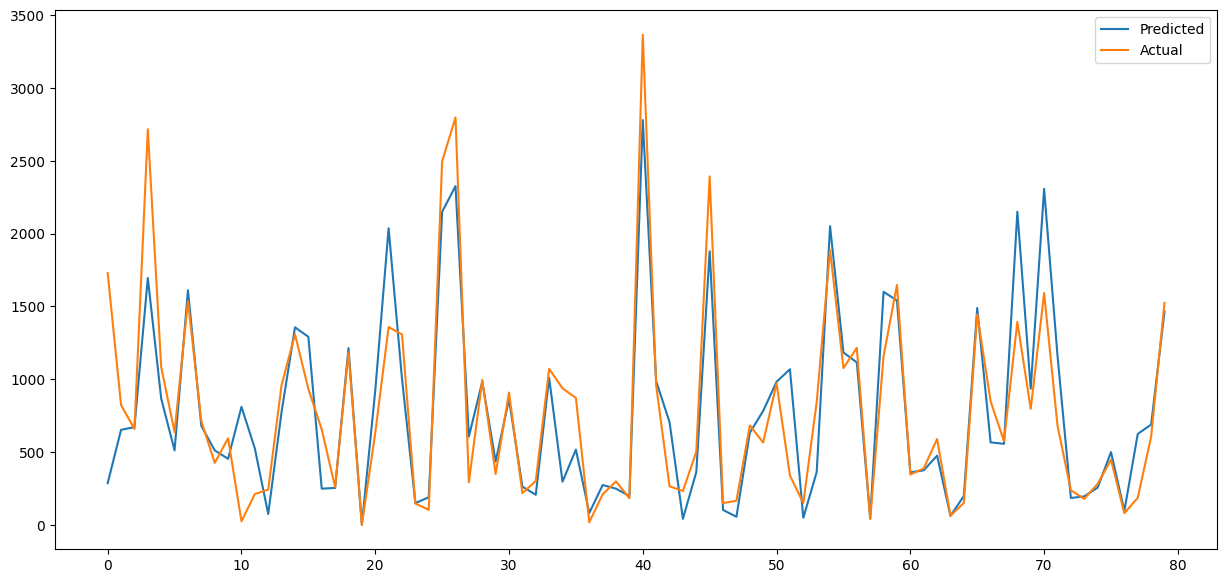

In [377]:
d_tree = DecisionTreeRegressor()
score_metrix(DecisionTreeRegressor(),x_train,x_test,y_train,y_test)

### **Using Random Forest Regressor**

Training score  = 0.981991800882314
Testing score =  0.8681009194274867
MAE : 151.1734589041096
MSE : 54955.255677739726
RMSE : 234.42537336589598
R2 : 0.8681009194274867
Adjusted R2 :  0.8654890564458527 

********************************************************************************


******************** ploting the graph of Actual and predicted only with 80 observation ********************


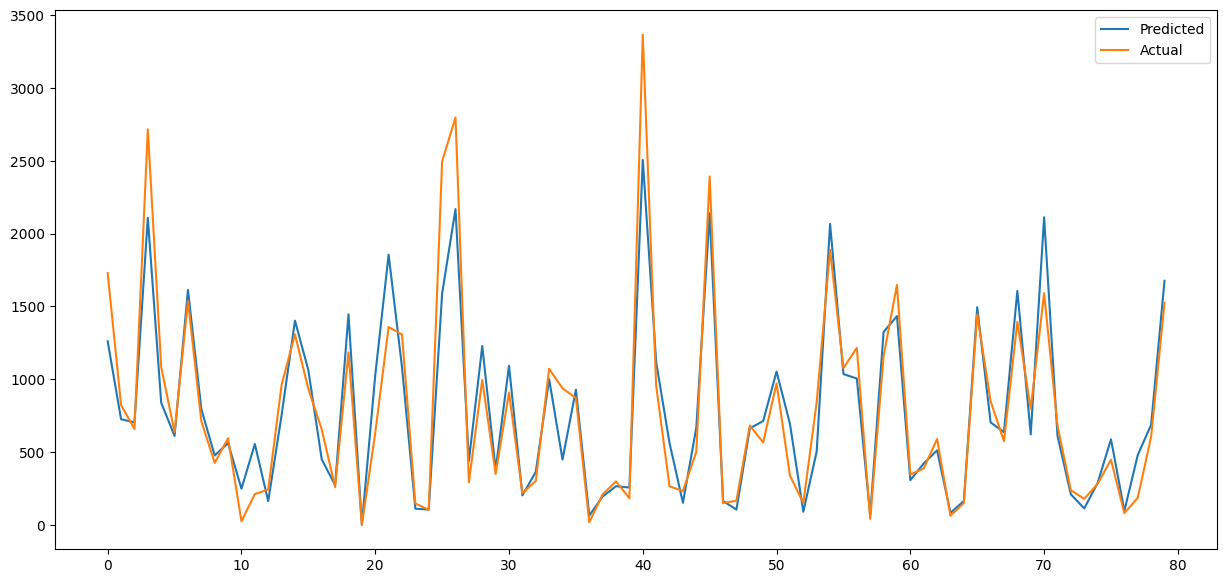

In [378]:
best_model = RandomForestRegressor()
score_metrix(RandomForestRegressor(),x_train,x_test,y_train,y_test)

### **Gradient Boosting Regressor**

Training score  = 0.8125624926972759
Testing score =  0.7903765595652636
MAE : 205.22421391525472
MSE : 87338.81779263169
RMSE : 295.5314159148426
R2 : 0.7903765595652636
Adjusted R2 :  0.7862256003487342 

********************************************************************************


******************** ploting the graph of Actual and predicted only with 80 observation ********************


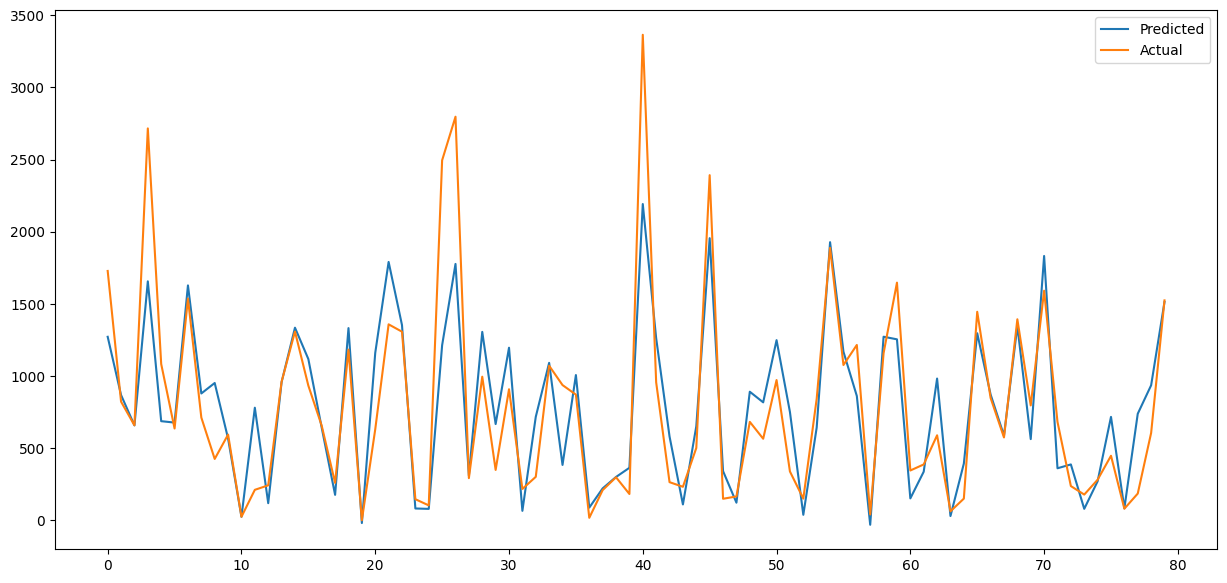

In [379]:
score_metrix(GradientBoostingRegressor(),x_train,x_test,y_train,y_test)

### **Adaboost Boost Regressor**

Training score  = 0.5664099935965019
Testing score =  0.5509246165844034
MAE : 367.7200645990773
MSE : 187105.56894758245
RMSE : 432.5570123666734
R2 : 0.5509246165844034
Adjusted R2 :  0.5420320347345896 

********************************************************************************


******************** ploting the graph of Actual and predicted only with 80 observation ********************


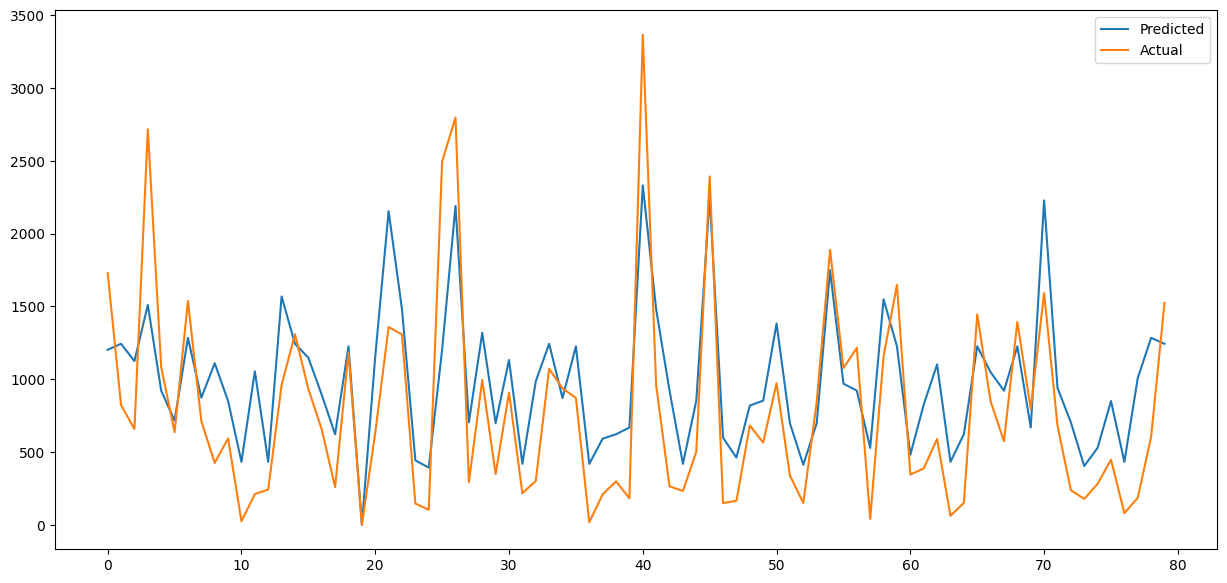

In [380]:
score_metrix(AdaBoostRegressor(),x_train,x_test,y_train,y_test)

### **KNN Regressor**

Training score  = 0.8712424432612392
Testing score =  0.7746508915199148
MAE : 202.87625570776254
MSE : 93890.85821917807
RMSE : 306.4161520207087
R2 : 0.7746508915199148
Adjusted R2 :  0.7701885329361507 

********************************************************************************


******************** ploting the graph of Actual and predicted only with 80 observation ********************


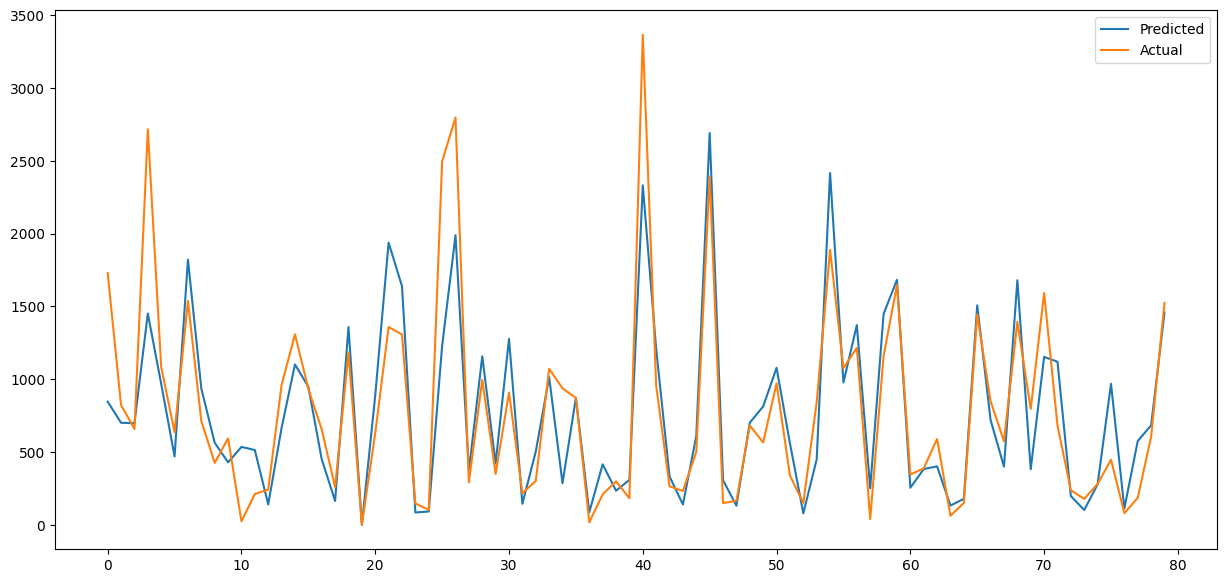

In [381]:
score_metrix(KNeighborsRegressor(),x_train,x_test,y_train,y_test)

In [382]:
import pickle

# Train the Random Forest Regressor model
best_model = RandomForestRegressor()
best_model.fit(x_train, y_train)

# Save the trained model as a pickle file
filename = 'best_model.pkl'
pickle.dump(best_model, open(filename, 'wb'))

print(f"Model saved as {filename}")

Model saved as best_model.pkl
